<a href="https://colab.research.google.com/github/BrenoMafra13/COMP3132-Machine_Learning/blob/main/labs/Lab_Week10/LabWeek10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 ## Lab - Week 10 - Dropout

### Ways to reduce overfitting in neural networks
 - Getting more training data
 - Reducing the capacity of the network (last week's lab)
 - Adding weight regularization (last week's lab)
 - Adding dropout (the subject for this week)
 - Using transfer learning

### Typical training and validation loss over time
![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*0VWDpLIRcMTssDf-zyOR4w.jpeg)

## Dropout Regularization

**Dropout** is a regularization technique that involves randomly "dropping out" (setting to zero) a subset of a layer's output features during training.

For example, if a layer would normally return the vector `[0.2, 0.5, 1.3, 0.8, 1.1]` for a specific input, applying dropout might result in `[0, 0.5, 1.3, 0, 1.1]`. The **dropout rate** defines the fraction of features zeroed out and typically ranges between 0.2 and 0.5.

At test time, no units are dropped. To compensate for the fact that all neurons are now active (unlike during training), the layer’s output values are scaled down by a factor equal to the dropout rate. This ensures that the expected sum of the inputs to the next layer remains consistent between training and inference.


![dropout](https://cdn-images-1.medium.com/max/1600/1*iWQzxhVlvadk6VAJjsgXgg.png)

In Keras you can introduce dropout in a network via the `Dropout` layer, which gets applied to the output of layer right before it, e.g.:
```python
model.add(layers.Dropout(0.5))
```

### Part 1: Load and Prepare Data - IMDB dataset

In [1]:
from keras import models
from keras import layers
from keras.datasets import imdb
import numpy as np

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
      for j in sequence:
        results[i, j] += 1
    return results

# Our vectorized training data
x_train = vectorize_sequences(train_data)
# Our vectorized test data
x_test = vectorize_sequences(test_data)
# Our vectorized labels
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**As a routine, perform a sanity check on the dataset to understand the shape of the train and test inputs and outputs, and print out a sample of the data.**

In [2]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)
print("First training review (vectorized, first 50 features):")
print(x_train[0][:50])
print("First training label:", y_train[0])

x_train shape: (25000, 10000)
y_train shape: (25000,)
x_test shape: (25000, 10000)
y_test shape: (25000,)
First training review (vectorized, first 50 features):
[ 0.  1.  6.  0. 15.  9.  3.  2.  3.  1.  0.  0.  6.  3.  3.  4. 11.  3.
  3.  2.  0.  1.  6.  0.  0.  4.  3.  0.  2.  0.  1.  0.  3.  2.  0.  1.
  4.  0.  4.  1.  0.  0.  0.  4.  0.  0.  1.  0.  1.  0.]
First training label: 1.0


### Part 2: Build a Simple Neural Network Model
Objective: Create a basic neural network model using Keras.

**Questions**
- What type of classification problem are we solving?
- How many neurons should there be in the output layer?
- What should be the activation function of the output layer?
- What loss function should be used?
- What activation function should be used on the hidden layers?


Build a sequential model with one dense layer with 8 units and train it for 20 epochs.

Complete the code below:

In [3]:
model = models.Sequential()
model.add(layers.InputLayer(shape=(10000,)))
model.add(layers.Dense(8, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │        80,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,017 (312.57 KB)

 Trainable params: 80,017 (312.57 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train the model
hist_a = model.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))

# Evaluate the model
evaluation_results = model.evaluate(x_test, y_test)
print("Test accuracy:", evaluation_results[1])

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - acc: 0.7927 - loss: 0.5105 - val_acc: 0.8650 - val_loss: 0.4066
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - acc: 0.8909 - loss: 0.3364 - val_acc: 0.8844 - val_loss: 0.3320
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9110 - loss: 0.2706 - val_acc: 0.8877 - val_loss: 0.3047
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.9234 - loss: 0.2341 - val_acc: 0.8904 - val_loss: 0.2905
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9295 - loss: 0.2110 - val_acc: 0.8874 - val_loss: 0.2923
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9359 - loss: 0.1935 - val_acc: 0.8891 - val_loss: 0.2845
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - acc: 0.9416 - loss: 0.1779 - val_acc: 0.8879 - val_loss: 0.2877
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.9444 - loss: 0.1665 - val_acc: 0.8858 - val_loss: 0.2946
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9491

### Part 3: Visualize Training and Validation Performance

The function below can be used later to plot the loss and accuracy from the model training history

In [11]:
# Helper function

import matplotlib.pyplot as plt
# colors will be used to plot the different models below
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

def plot_history(history, color='blue', prefix=""):
    history_dict = history.history
    loss_values = history_dict["loss"]
    val_loss_values = history_dict["val_loss"]
    epochs = range(1, len(loss_values) + 1)

    # Make a figure with two subplots side by side
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)

    # Plot the loss
    plt.plot(epochs, loss_values, "o",  color=color, label=prefix + " Training loss")
    plt.plot(epochs, val_loss_values, color=color, label=prefix + " Validation loss")
    plt.title("Training and validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(framealpha=0.5)
    plt.grid()

    # Plot the accuracy
    plt.subplot(1, 2, 2)
    acc_values = history_dict["acc"]
    val_acc_values = history_dict["val_acc"]
    # Skip plotting the training accuracy, it makes the plot harder to read
    # plt.plot(epochs, acc_values, "o", color=color , label=prefix + " Training accuracy")
    plt.plot(epochs, val_acc_values, color=color, label=prefix + " Validation accuracy")
    plt.title("Training and validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(framealpha=0.5)
    plt.grid()

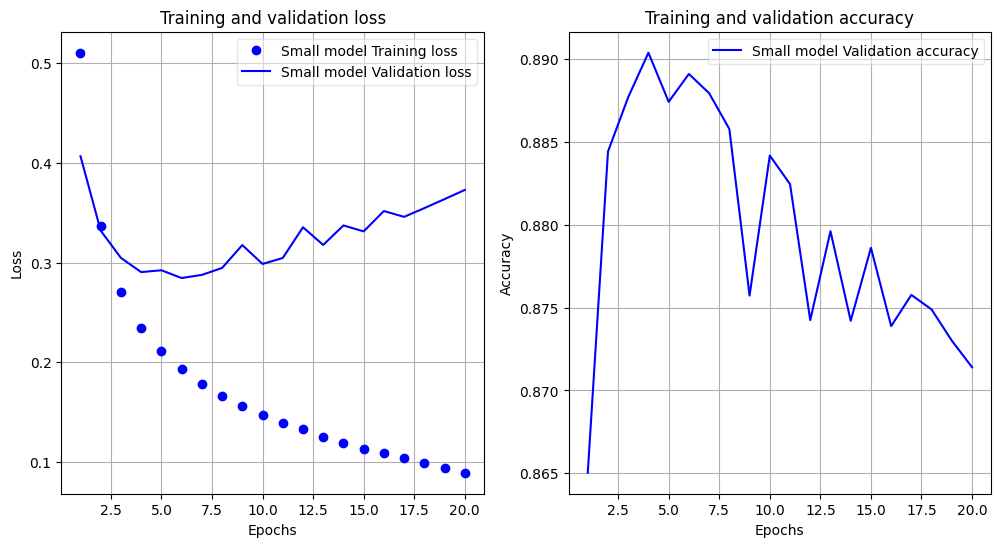

In [12]:
# Using the plotting function

plot_history(hist_a, color='blue', prefix="Small model")

### Part 4: Add Dropout Regularization
Objective: Experiment with dropout layers in the model.

**Instructions:**
1. Add another hidden layer with 8 units
1. Add dropout layers after each hidden layer with a dropout rate of 0.3.
1. Compile the model.
1. Train the model and observe the changes in accuracy.

Complete the code below:

In [4]:
drp_model = models.Sequential()
drp_model.add(layers.InputLayer(shape=(10000,)))
drp_model.add(layers.Dense(8, activation='relu'))
drp_model.add(layers.Dropout(0.3))
drp_model.add(layers.Dense(8, activation='relu'))
drp_model.add(layers.Dropout(0.3))
drp_model.add(layers.Dense(1, activation='sigmoid'))
drp_model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

drp_history = drp_model.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - acc: 0.6799 - loss: 0.6070 - val_acc: 0.8427 - val_loss: 0.4956
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.7930 - loss: 0.4845 - val_acc: 0.8724 - val_loss: 0.4024
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.8432 - loss: 0.4117 - val_acc: 0.8795 - val_loss: 0.3471
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.8721 - loss: 0.3568 - val_acc: 0.8803 - val_loss: 0.3206
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.8885 - loss: 0.3160 - val_acc: 0.8876 - val_loss: 0.2955
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9039 - loss: 0.2773 - val_acc: 0.8785 - val_loss: 0.2975
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.9161 - loss: 0.2499 - val_acc: 0.8866 - val_loss: 0.3023
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - acc: 0.9220 - loss: 0.2321 - val_acc: 0.8802 - val_loss: 0.2921
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.929

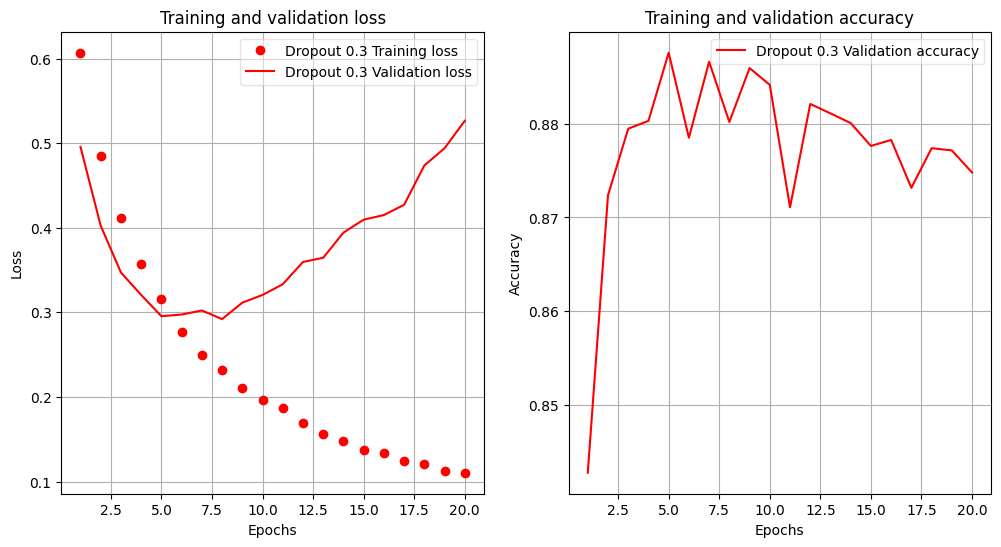

In [13]:
# Plot training history
plot_history(drp_history, color='red', prefix="Dropout 0.3")

### Part 5: Test Different Dropout Rates
Objective: Compare the model's performance with varying dropout rates.

**Instructions:**
1. Write a loop to create and train models with dropout rates of `[0, 0.2, 0.3, 0.4, 0.5]`.
2. For each model, record the history to plot it later


Complete the code below:

In [6]:
rates = [0, 0.2, 0.3, 0.4, 0.5]
hists = []

for rate in rates:
    print(f"Training model with dropout rate: {rate}")
    model = models.Sequential()
    model.add(layers.InputLayer(shape=(10000,)))
    if rate > 0:
        model.add(layers.Dropout(rate))
    model.add(layers.Dense(8, activation='relu'))
    if rate > 0:
        model.add(layers.Dropout(rate))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

    hist = model.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))
    hists.append(hist)

Training model with dropout rate: 0
Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - acc: 0.7480 - loss: 0.5686 - val_acc: 0.8539 - val_loss: 0.4466
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.8845 - loss: 0.3747 - val_acc: 0.8854 - val_loss: 0.3514
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9096 - loss: 0.2882 - val_acc: 0.8877 - val_loss: 0.3139
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9214 - loss: 0.2446 - val_acc: 0.8848 - val_loss: 0.3065
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.9311 - loss: 0.2140 - val_acc: 0.8873 - val_loss: 0.2966
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.9377 - loss: 0.1919 - val_acc: 0.8807 - val_loss: 0.3082
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9423 - loss: 0.1760 - val_acc: 0.8883 - val_loss: 0.2889
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9474 - loss: 0.1624 - val_acc: 0.8866 - val_loss: 0.2910
Epoch 9/20
49/49 ━━━━━━━━━━━

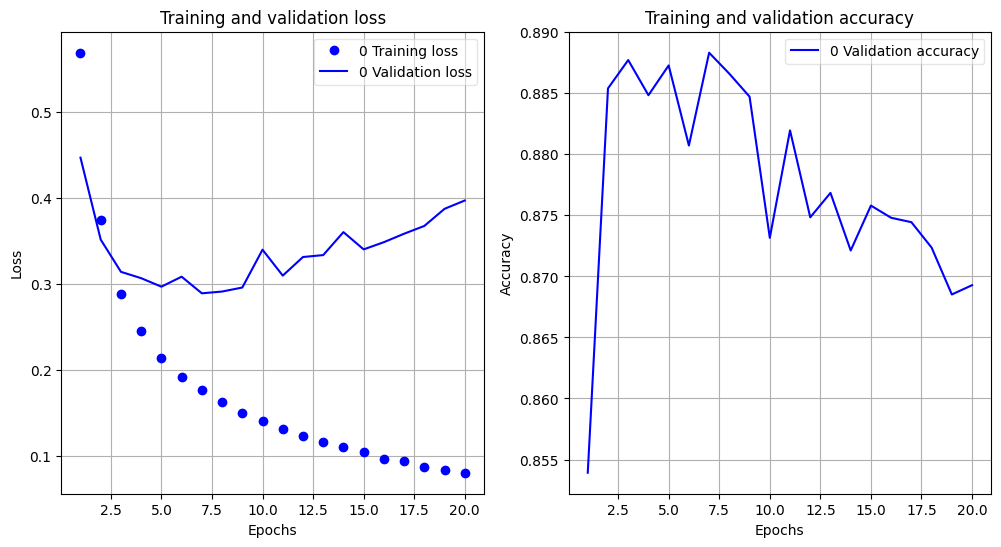

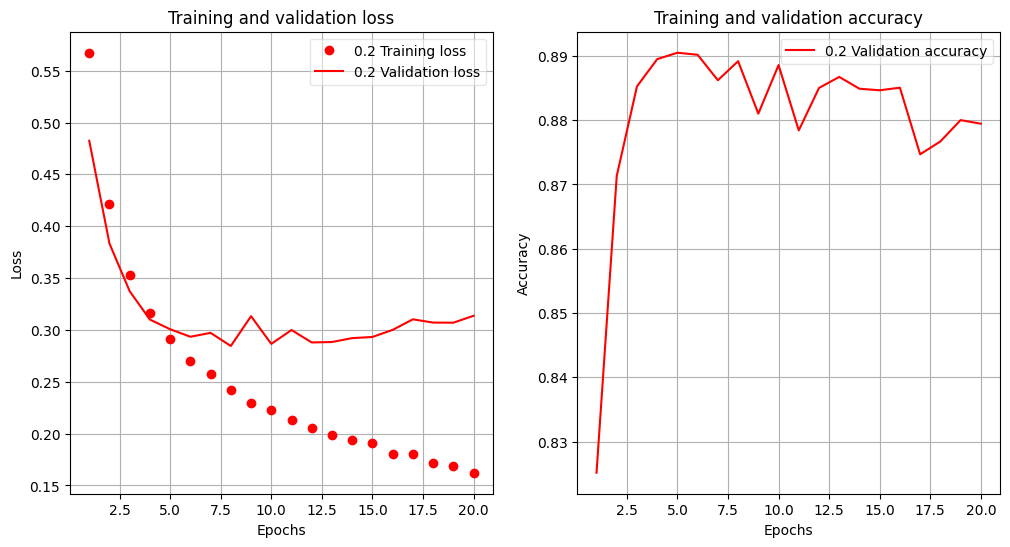

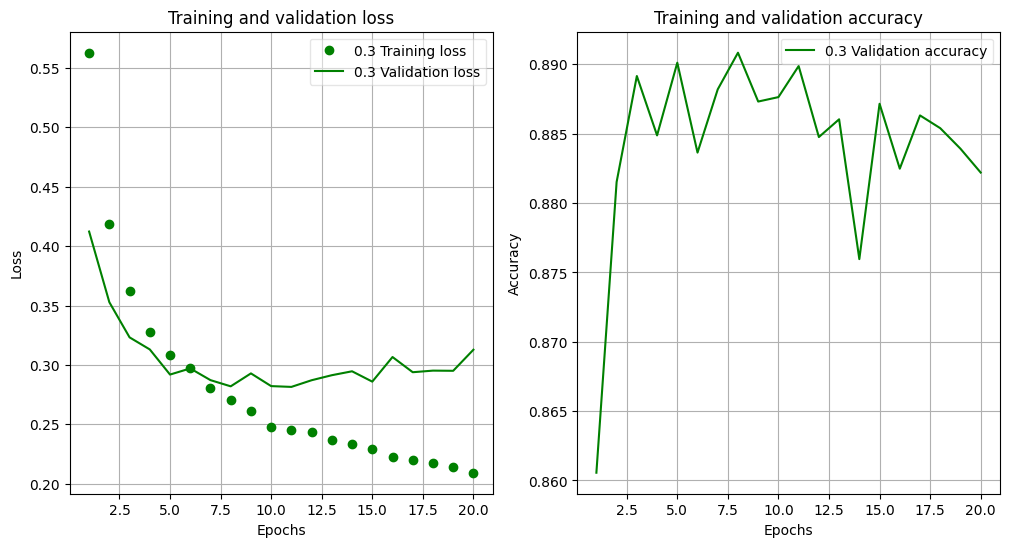

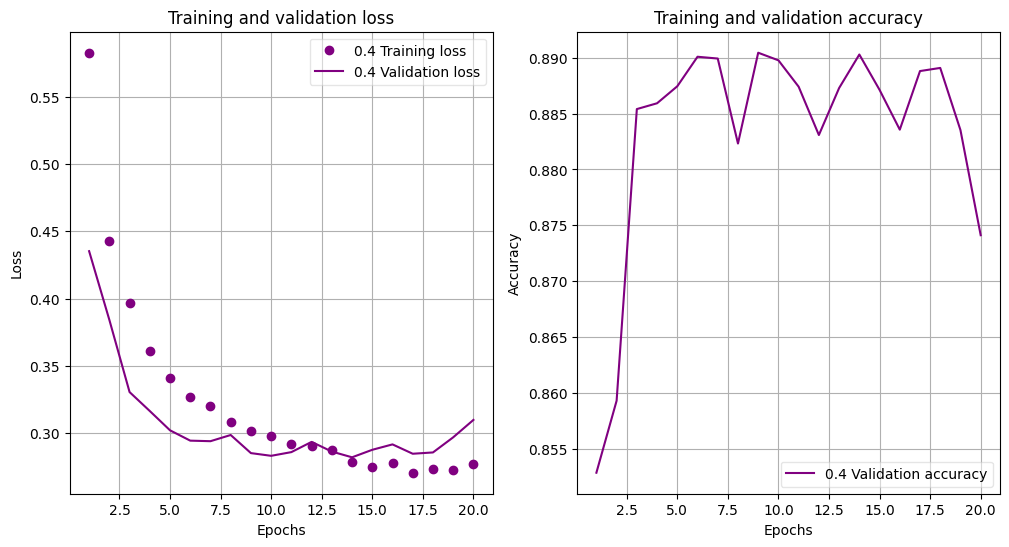

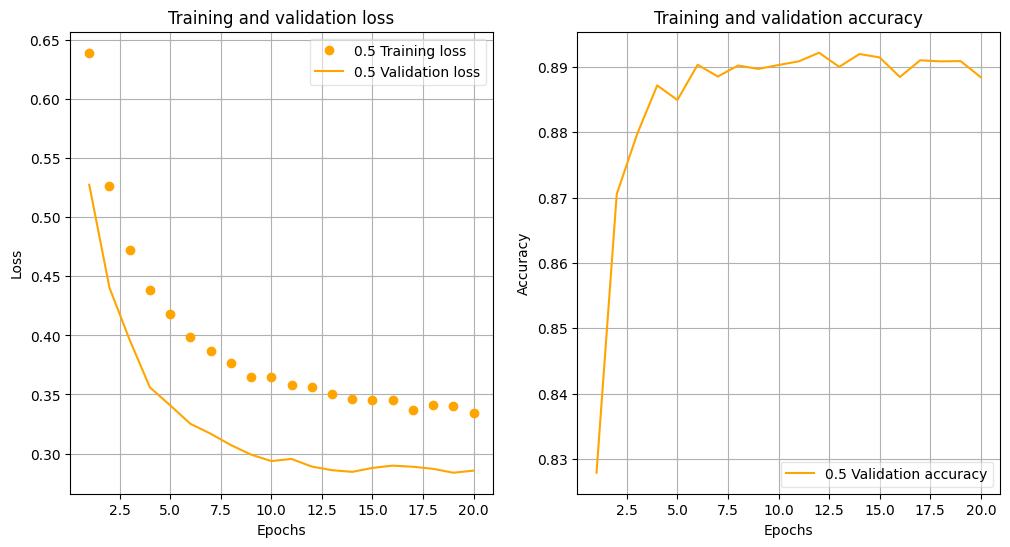

In [14]:
for i, hist in enumerate(hists):
    plot_history(hist, colors[i], prefix=str(rates[i]))

### Part 6: Experiment with dropout location
Objective: Compare the model's performance with dropout placed after different layers

**Instructions:**
Create 3 models with a single dropout "layer" placed:
1. Before the first dense layer only
2. After the first dense layer only
3. After the second dense layer only



Complete the code below:

In [7]:
hists_b = []
rate = 0.4

# Model 1: Dropout before the first dense layer
model1 = models.Sequential()
model1.add(layers.InputLayer(shape=(10000,)))
model1.add(layers.Dropout(rate))
model1.add(layers.Dense(8, activation='relu'))
model1.add(layers.Dense(8, activation='relu'))
model1.add(layers.Dense(1, activation='sigmoid'))
model1.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
print("Training model with dropout before 1st layer")
hist1 = model1.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))
hists_b.append(hist1)

# Model 2: Dropout after the first dense layer
model2 = models.Sequential()
model2.add(layers.InputLayer(shape=(10000,)))
model2.add(layers.Dense(8, activation='relu'))
model2.add(layers.Dropout(rate))
model2.add(layers.Dense(8, activation='relu'))
model2.add(layers.Dense(1, activation='sigmoid'))
model2.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
print("Training model with dropout after 1st layer")
hist2 = model2.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))
hists_b.append(hist2)

# Model 3: Dropout after the second dense layer
model3 = models.Sequential()
model3.add(layers.InputLayer(shape=(10000,)))
model3.add(layers.Dense(8, activation='relu'))
model3.add(layers.Dense(8, activation='relu'))
model3.add(layers.Dropout(rate))
model3.add(layers.Dense(1, activation='sigmoid'))
model3.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
print("Training model with dropout after 2nd layer")
hist3 = model3.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))
hists_b.append(hist3)

Training model with dropout before 1st layer
Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - acc: 0.7468 - loss: 0.5549 - val_acc: 0.8631 - val_loss: 0.4233
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - acc: 0.8509 - loss: 0.3906 - val_acc: 0.8831 - val_loss: 0.3456
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - acc: 0.8697 - loss: 0.3333 - val_acc: 0.8888 - val_loss: 0.3142
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - acc: 0.8837 - loss: 0.3006 - val_acc: 0.8868 - val_loss: 0.3062
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - acc: 0.8876 - loss: 0.2900 - val_acc: 0.8918 - val_loss: 0.2917
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - acc: 0.8921 - loss: 0.2759 - val_acc: 0.8846 - val_loss: 0.3003
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.8974 - loss: 0.2645 - val_acc: 0.8881 - val_loss: 0.2916
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.8989 - loss: 0.2594 - val_acc: 0.8883 - val_loss: 0.2901
Epoch 9/20
49/49 ━━

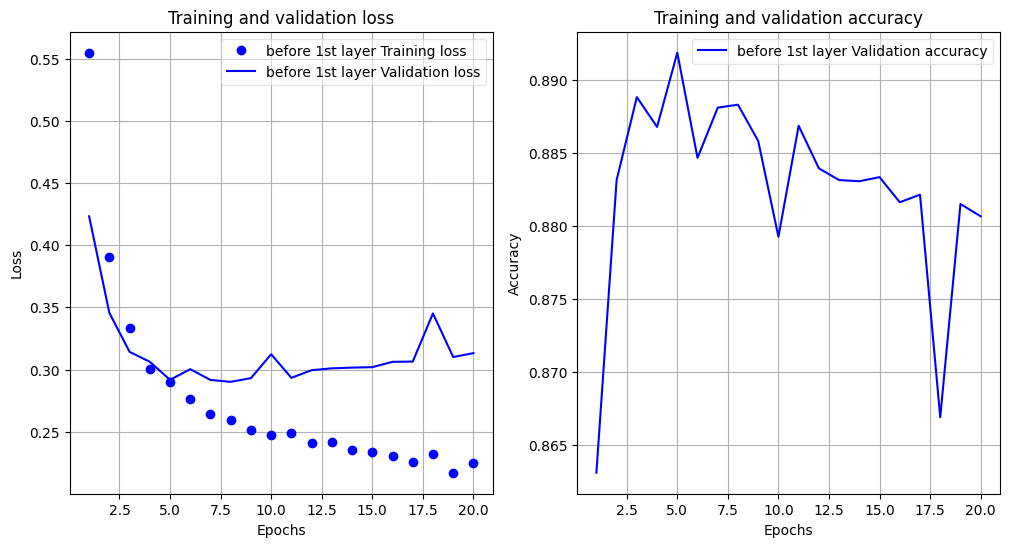

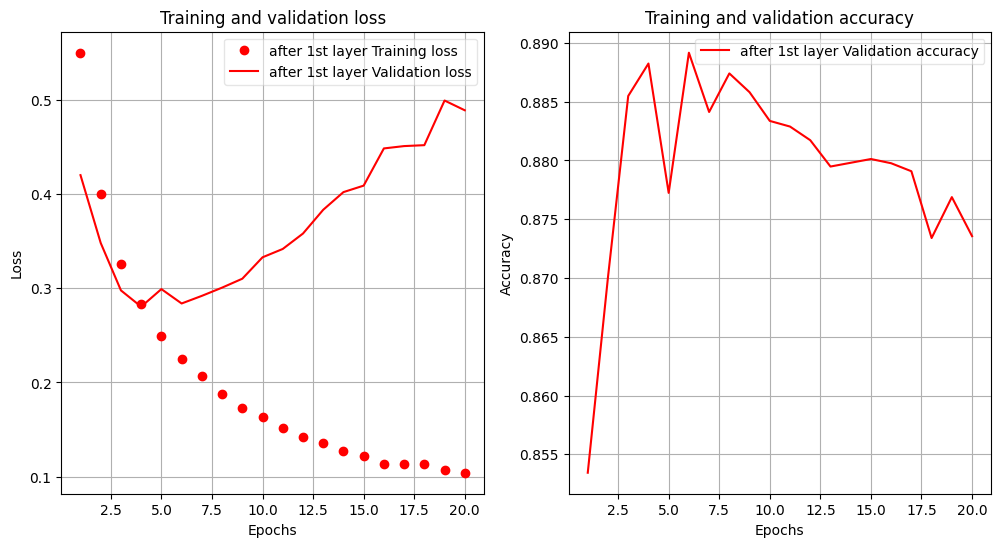

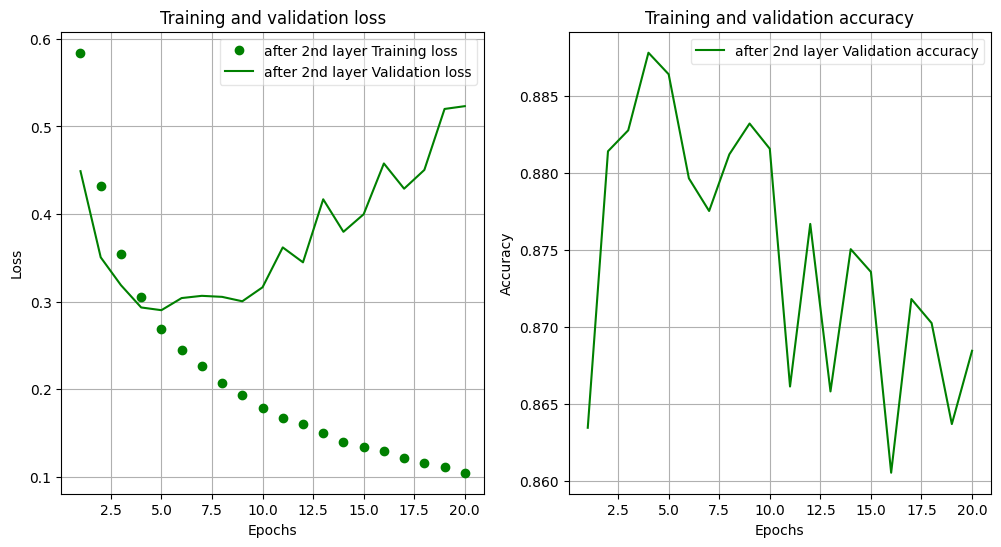

In [15]:
prefixes = ['before 1st layer', 'after 1st layer', 'after 2nd layer']
for i, hist in enumerate(hists_b):
    plot_history(hist, colors[i], prefix=prefixes[i])